In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
sns.set_theme(style='whitegrid')
fig = plt.figure(figsize=(20, 24))

loan_dataset=pd.read_csv("data/student-por.csv")
loan_dataset.head().T

,0,1,2,3,4
school,GP,GP,GP,GP,GP
sex,F,F,F,F,F
age,18,17,15,15,16
address,U,U,U,U,U
famsize,GT3,GT3,LE3,GT3,GT3
Pstatus,A,T,T,T,T
Medu,4,1,1,4,3
Fedu,4,1,1,2,3
Mjob,at_home,at_home,at_home,health,other
Fjob,teacher,other,other,services,other


<Figure size 2000x2400 with 0 Axes>

In [78]:
loan_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [79]:
loan_dataset.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
school,649,2,GP,423,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,649,2,F,383,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,649.0,NaN,NaN,NaN,16.744222,1.218138,15.0,16.0,17.0,18.0,22.0
address,649,2,U,452,NaN,NaN,NaN,NaN,NaN,NaN,NaN
famsize,649,2,GT3,457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pstatus,649,2,T,569,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medu,649.0,NaN,NaN,NaN,2.514638,1.134552,0.0,2.0,2.0,4.0,4.0
Fedu,649.0,NaN,NaN,NaN,2.306626,1.099931,0.0,1.0,2.0,3.0,4.0
Mjob,649,5,other,258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fjob,649,5,other,367,NaN,NaN,NaN,NaN,NaN,NaN,NaN


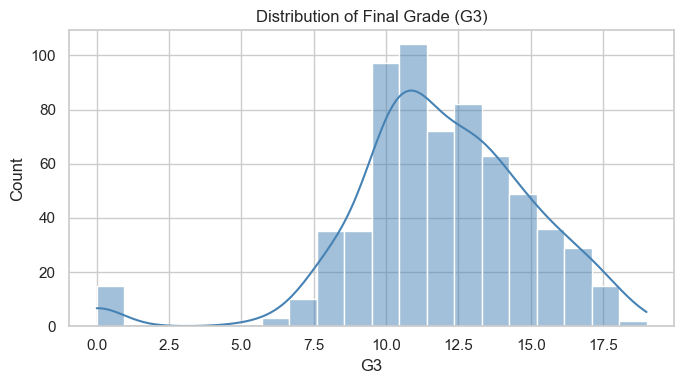

In [80]:
# 1. G3 Distribution
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(loan_dataset['G3'], kde=True, bins=20, color='steelblue', ax=ax)
ax.set_title('Distribution of Final Grade (G3)')
ax.set_xlabel('G3')
plt.tight_layout()
plt.show()

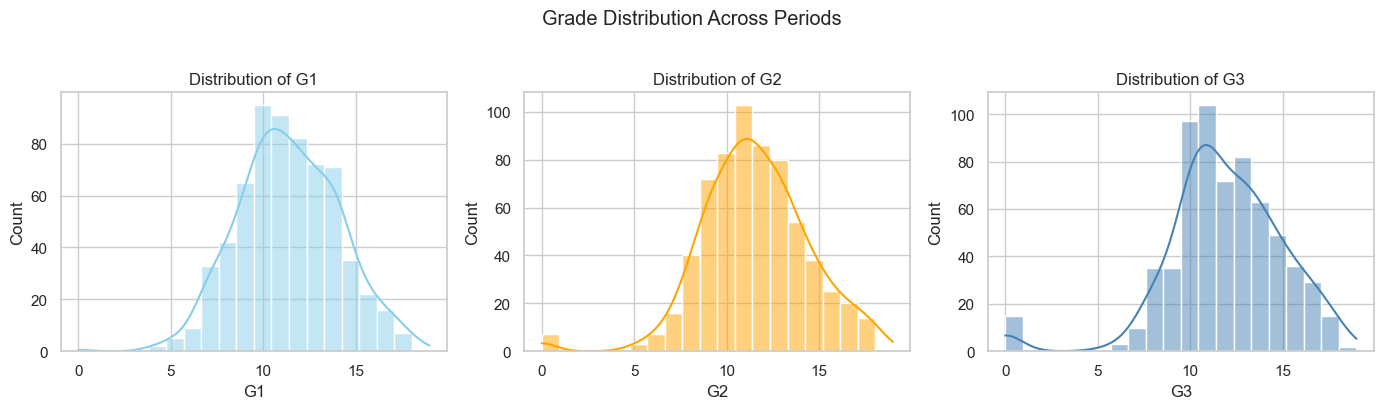

In [81]:
# 2. G1, G2, G3 — subplot per period
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, color in zip(axes, ['G1', 'G2', 'G3'], ['skyblue', 'orange', 'steelblue']):
    sns.histplot(loan_dataset[col], kde=True, bins=20, color=color, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
plt.suptitle('Grade Distribution Across Periods', y=1.02)
plt.tight_layout()
plt.show()

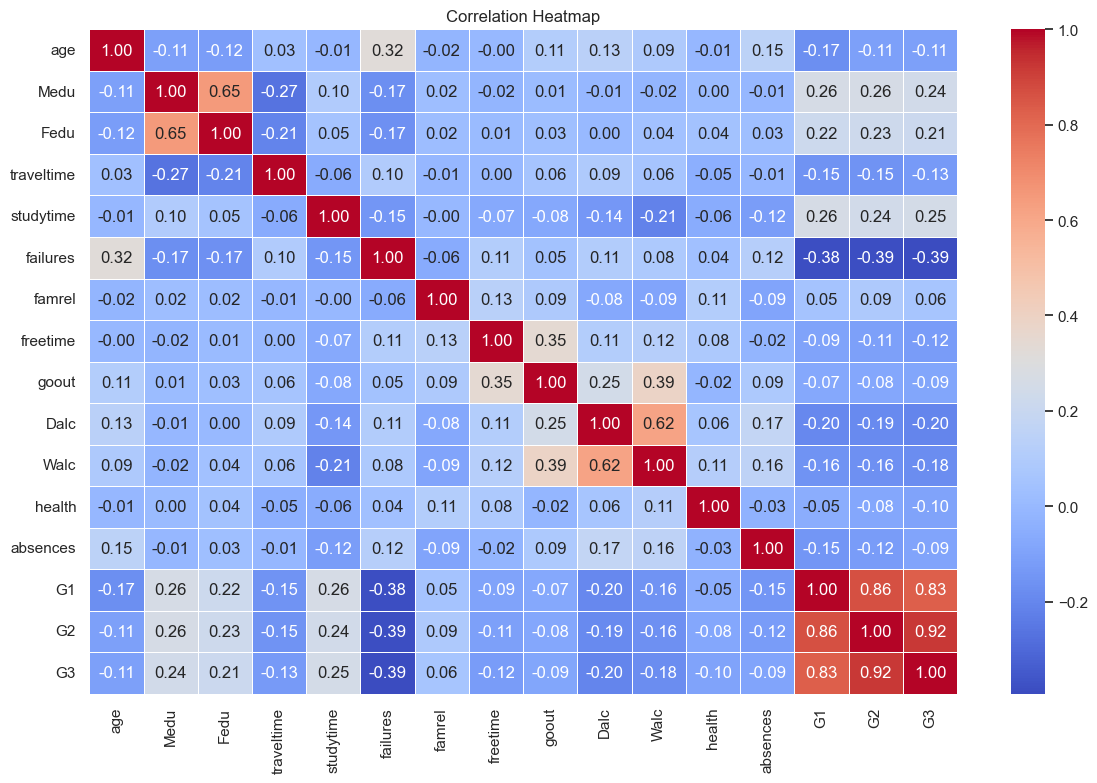

In [82]:
# 3. Correlation Heatmap
fig, ax = plt.subplots(figsize=(12, 8))
numeric_cols = loan_dataset.select_dtypes(include='number').columns
sns.heatmap(loan_dataset[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_12760\2743325626.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=loan_dataset, x='higher', y='G3', palette='Set2', ax=ax)


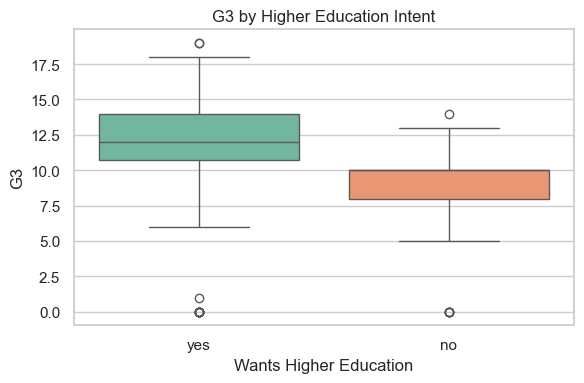

In [83]:
# 4. G3 by Higher Education Intent
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=loan_dataset, x='higher', y='G3', palette='Set2', ax=ax)
ax.set_title('G3 by Higher Education Intent')
ax.set_xlabel('Wants Higher Education')
plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_12760\1184589082.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=loan_dataset, x='sex', y='G3', palette='pastel', ax=ax)


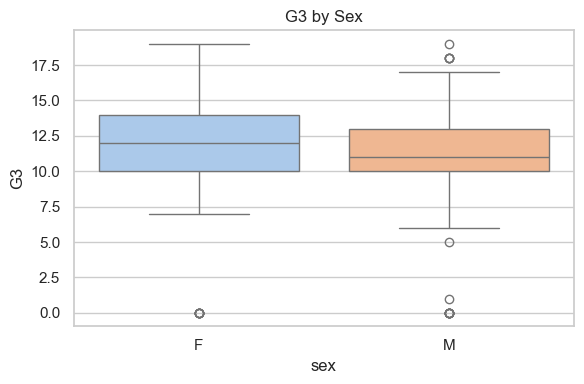

In [84]:
# 5. G3 by Sex
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=loan_dataset, x='sex', y='G3', palette='pastel', ax=ax)
ax.set_title('G3 by Sex')
plt.tight_layout()
plt.show()

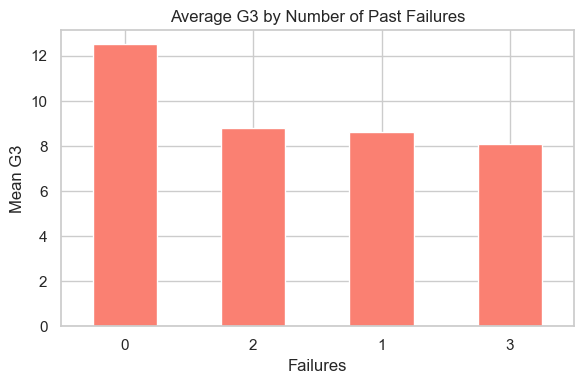

In [85]:
# 6. Failures vs Mean G3
fig, ax = plt.subplots(figsize=(6, 4))
loan_dataset.groupby('failures')['G3'].mean().sort_values(ascending=False).plot(kind='bar', color='salmon', ax=ax)
ax.set_title('Average G3 by Number of Past Failures')
ax.set_xlabel('Failures')
ax.set_ylabel('Mean G3')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_12760\3764849486.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=loan_dataset, x=col, y='G3', palette='muted', ax=ax)
C:\Users\HP\AppData\Local\Temp\ipykernel_12760\3764849486.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=loan_dataset, x=col, y='G3', palette='muted', ax=ax)


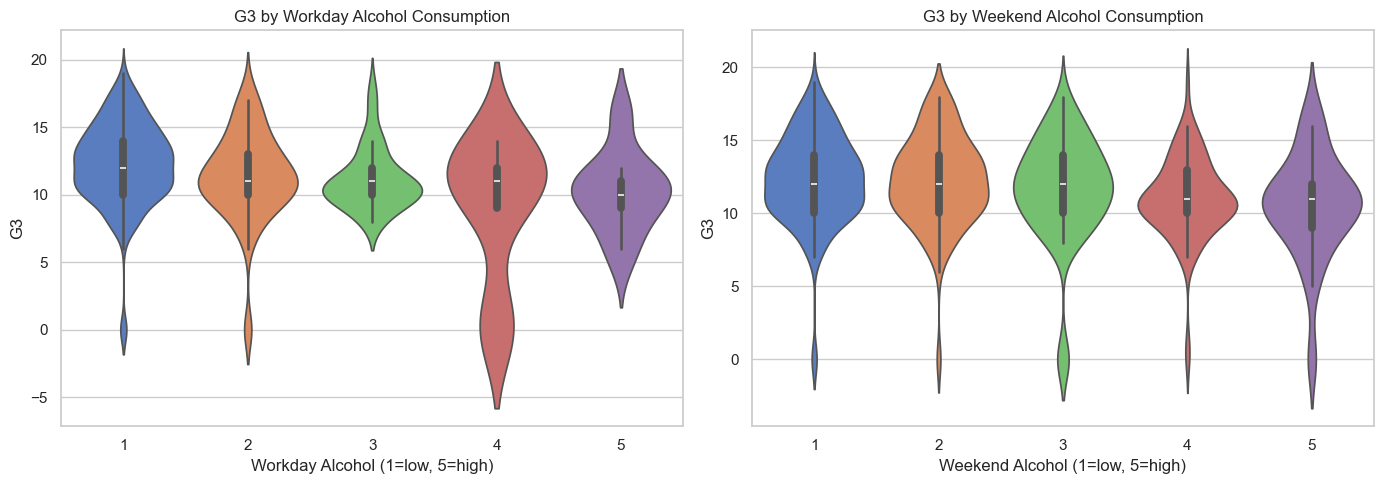

In [86]:
# 7. Alcohol consumption (Dalc & Walc) vs G3 — subplot per type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, label in zip(axes, ['Dalc', 'Walc'], ['Workday', 'Weekend']):
    sns.violinplot(data=loan_dataset, x=col, y='G3', palette='muted', ax=ax)
    ax.set_title(f'G3 by {label} Alcohol Consumption')
    ax.set_xlabel(f'{label} Alcohol (1=low, 5=high)')
plt.tight_layout()
plt.show()

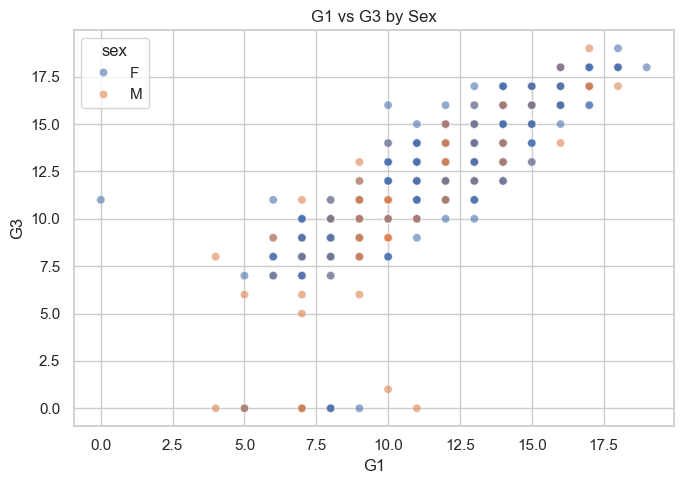

In [87]:
# 8. G1 vs G3 Scatter
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=loan_dataset, x='G1', y='G3', hue='sex', alpha=0.6, ax=ax)
ax.set_title('G1 vs G3 by Sex')
plt.tight_layout()
plt.show()

In [88]:
missing=loan_dataset.isna().sum().sum()
dublicate=loan_dataset.duplicated().sum()

print('number of missing values ',missing)
print("number of dublicated rows ",dublicate)

number of missing values  0
number of dublicated rows  0


In [89]:
loan_dataset['pass'] = (loan_dataset['G3'] >= 10).astype(int)

print(loan_dataset['pass'].value_counts())
print(f"\nPass rate: {loan_dataset['pass'].mean():.1%}")

pass
1    549
0    100
Name: count, dtype: int64

Pass rate: 84.6%


In [90]:
df_model = loan_dataset.drop(columns=['G3']) 

cat_cols = df_model.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

print("Encoded columns:", list(cat_cols))
df_model.head()

Encoded columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,pass
0,0,0,18,1,0,0,4,4,0,4,...,4,3,4,1,1,3,4,0,11,1
1,0,0,17,1,0,1,1,1,0,2,...,5,3,3,1,1,3,2,9,11,1
2,0,0,15,1,1,1,1,1,0,2,...,4,3,2,2,3,3,6,12,13,1
3,0,0,15,1,0,1,4,2,1,3,...,3,2,2,1,1,5,0,14,14,1
4,0,0,16,1,0,1,3,3,2,2,...,4,3,2,1,2,5,0,11,13,1


In [91]:
X = df_model.drop(columns=['pass'])
y = df_model['pass']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Train size: 519 | Test size: 130


In [92]:
# ── Cell 5 · Train 4 Models ───────────────────────────────────────
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name:25s} → Accuracy: {acc:.4f}")

Logistic Regression       → Accuracy: 0.9000
Decision Tree             → Accuracy: 0.8615
Random Forest             → Accuracy: 0.9231
Gradient Boosting         → Accuracy: 0.9231


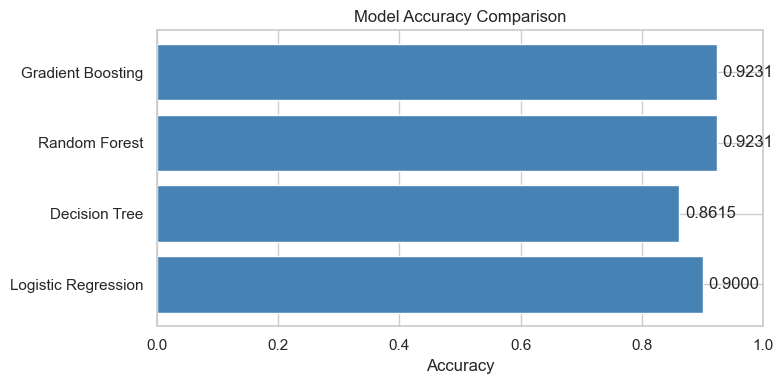

In [93]:
# ── Cell 6 · Model Accuracy Comparison ───────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(list(results.keys()), list(results.values()), color='steelblue')
ax.bar_label(bars, fmt='%.4f', padding=4)
ax.set_xlim(0, 1)
ax.set_title('Model Accuracy Comparison')
ax.set_xlabel('Accuracy')
plt.tight_layout()
plt.show()

In [94]:
# ── Cell 7 · Best Model — Classification Report ───────────────────
best_name = max(results, key=results.get)
best_model = models[best_name]
preds = best_model.predict(X_test)

print(f"Best model: {best_name}\n")
print(classification_report(y_test, preds, target_names=['Fail', 'Pass']))

Best model: Random Forest

              precision    recall  f1-score   support

        Fail       0.78      0.70      0.74        20
        Pass       0.95      0.96      0.95       110

    accuracy                           0.92       130
   macro avg       0.86      0.83      0.85       130
weighted avg       0.92      0.92      0.92       130



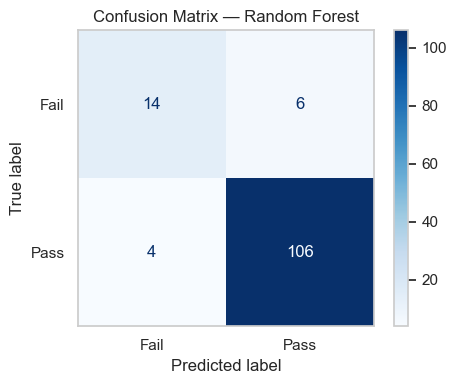

In [95]:
# ── Cell 8 · Confusion Matrix ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail', 'Pass'])
disp.plot(cmap='Blues', ax=ax)
ax.set_title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.grid(False)
plt.show()


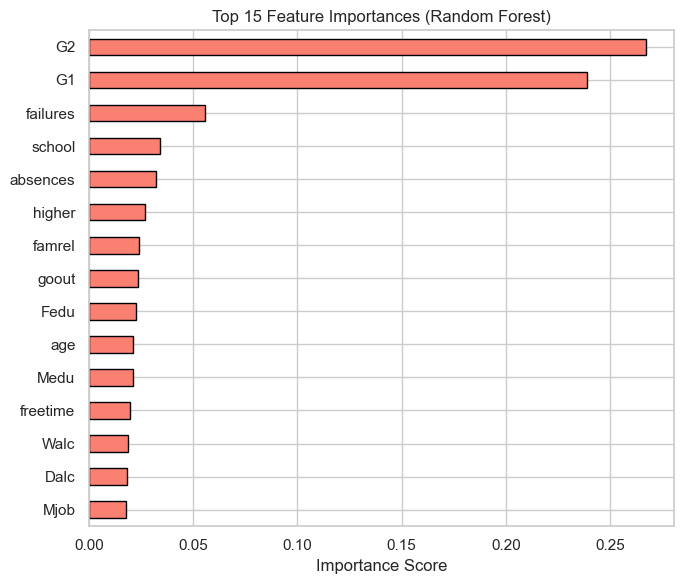

In [103]:
rf = models['Random Forest']
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(7, 6))
importances.plot(kind='barh', color='salmon', edgecolor='black', ax=ax)
ax.set_title('Top 15 Feature Importances (Random Forest)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()